# INSTRUCCIONES

## OBJETIVOS

Desarrollar competencias básicas para:

1. Modelar problemas para ser resueltos mediante técnicas de búsqueda adversaria en espacio de soluciones.
2. Implementar algoritmos de búsqueda adversaria: *Min-Max* y *Alpha-Beta*.
3. Resolver problemas de búsqueda adversaria en espacio de soluciones.

## ENTREGABLE

*Reglas para el envío de los entregables*:

- **Forma de envío:**

  Este laboratorio se debe enviar únicamente a través de la plataforma <ins>[Moodle](https://campusvirtual.escuelaing.edu.co/moodle/)</ins> en la actividad definida.

- **Archivo de entrega:**

  Incluyan en un archivo `.zip` los archivos correspondientes al laboratorio, revise <ins>**[How to cite in Jupyter Notebooks](https://gist.github.com/ELS4NTA/2c188b3b7300a726e60d71a58a55f740)**</ins> para citar cualquier recurso utilizado y ver la estructura del proyecto.

- **Nomenclatura para nombrar el archivo de entrega:**

  El archivo deberá ser renombrado en mayúsculas con el siguiente formato: `L02-{color_grupo}-IAIA-{semestre_academico}.zip`

  Ejemplos:

  ```txt
  L02-AZUL-IAIA-2026-2.zip
  L02-ROJO-IAIA-2026-2.zip
  ```

Revise cuando lo requiera <a href="https://aima.cs.berkeley.edu/global-index.html"><cite data-cite="russell2021artificial">(Russell & Norvig, 2021, cap. 6)</cite></a>

# I. DESARROLLANDO: BÚSQUEDA CON ADVERSARIO
## A. MODELAR BÚSQUEDA ADVERSARIA

### Modelen la estructura de datos para búsqueda adversaria:

Un `Game` que contenga:

* El *estado* inicial (`initial -> TState`)
* El jugador que tiene el turno en un estado (`player(TState) -> TPlayer`)
* El jugador adversario de un jugador dado (`opponent(TPlayer) -> TPlayer`)
* Si un estado ha finalizado el juego (`is_terminal(TState) -> bool`)
* La *función de transición* de un estado al aplicar las acciones de juego (`result_actions(TState) -> Set[TState]`)
* La *función de utilidad* de un jugador para un estado (`utility(TState, TPlayer) -> float`)

In [9]:
class Game:
    def __init__(self, initial_state, players):
        self.initial_state = initial_state
        self.players = players

    def player(self, state):
        pass

    def opponent(self, player):
        pass

    def is_terminal(self, state):
        return False

    def result_actions(self, state):
        return set()

    def utility(self, state, player):
        return 0.0

## B. IMPLEMENTAR

### Implemente el algoritmo de búsqueda adversaria Min-Max:

1. Implemente la función para el jugador $\color{64C1FF}{\text{MAX}}$ (`max_value(Game, TState) -> float`) que devuelve el valor máximo que el jugador $\color{64C1FF}{\text{MAX}}$ puede asegurar desde un estado dado.
2. Implemente la función para el jugador $\color{F8908F}{\text{MIN}}$ (`min_value(Game, TState) -> float`) que devuelve el valor mínimo que el jugador $\color{F8908F}{\text{MIN}}$ puede asegurar desde un estado dado.
3. Implemente el algoritmo Min-Max (`minimax_search(Game, TState) -> float`).

In [10]:
# ============================================================
# 1. Implemente la función para obtener el valor de un estado para MAX
# ============================================================
class MaxMinSearch:

    @staticmethod
    def max_value(game, state):
        if game.is_terminal(state):
            return game.utility(state, game.player(state))
        best_value = float('-inf')
        for successor in game.result_actions(state):
            value = MaxMinSearch.min_value(game, successor)
            best_value = max(best_value, value)
        return best_value

    @staticmethod
    def min_value(game, state):
        if game.is_terminal(state):
            return game.utility(state, game.player(state))
        worst_value = float ('inf')
        for successor in game.result_actions(state):
            value = MaxMinSearch.max_value(game, successor)
            worst_value = min(worst_value, value)
        return worst_value

    @staticmethod
    def minmax_search(game, state):
        if game.player(state) == game.players[0]:
            return MaxMinSearch.max_value(game, state)
        else:
            return MaxMinSearch.min_value(game, state)

In [11]:
# ============================================================
# 2. Implemente la función para obtener el valor de un estado para MIN
# ============================================================

In [12]:
# ============================================================
# 3. Implemente el algoritmo de búsqueda del Min-Max
# ============================================================

### Pruebe la implementación del algoritmo con el siguiente espacio de ejemplo:

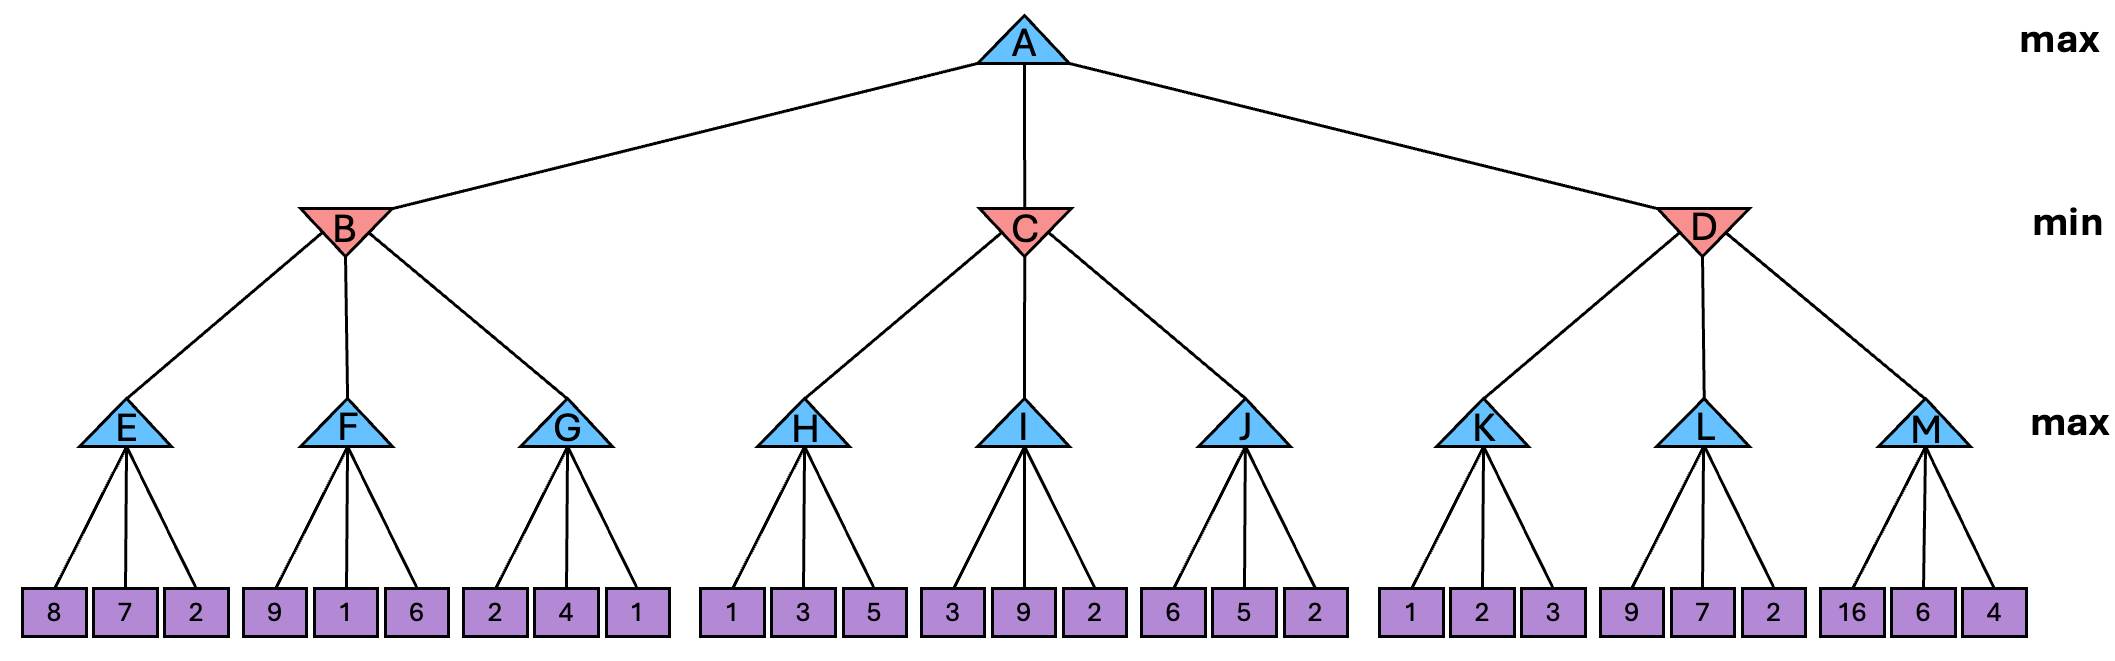

1. Implemente la función donde se juega por turnos e inicia un `TPlayer` dado `play_game(Game, TPlayer) -> Sequence[TState]`
2. Modele la representación del árbol de juego de ejemplo.
3. Use el algoritmo de búsqueda adversaria *Min-Max* para encontrar la utilidad de $\color{64C1FF}{\text{MAX}}$ en el estado inicial `A` del árbol de juego de ejemplo.
4. Presente la secuencia de acciones que tomará `J1` para maximizar su utilidad.

*Identifique los estados con letras del abecedario `A`, `B`, `C`,*\
*Los jugadores son `J1` y `J2`, $\color{64C1FF}{\text{MAX}}$ es el `J1`*

In [13]:
# ============================================================
# 1. Implemente la función que juega en base a un jugador dado (MAX o MIN)
# ============================================================
def play_game(game, player):
    state = game.initial_state
    steps = [state]

    while not game.is_terminal(state):
        shift = game.player(state)
        best_successor = None
        best_value = float('-inf') if shift == game.players[0] else float('inf')
        for successor in game.result_actions(state):
            value = MaxMinSearch.minmax_search(game, successor)
            if (shift == game.players[0]  and value > best_value) or (shift == game.players[1]  and value < best_value):
                best_value = value
                best_successor = successor

        state = best_successor
        steps.append(state)

    return steps


In [14]:
# ============================================================
# 2. Represente el espacio de búsqueda de ejemplo
# use como referencia el modelado del punto A
# ============================================================
from collections import deque
class TreeGame(Game):
    def __init__(self, initial_state, players, nodes):
        super().__init__(initial_state, players )
        self.nodes = nodes

    def is_terminal(self, state):
        return isinstance(state, (int, float))

    def depth(self, state):
        queue = deque()
        queue.append((self.initial_state, 0))
        while queue:
            node, node_depth = queue.popleft()
            if node == state:
                return node_depth
            if self.is_terminal(node):
                continue
            for successor in self.nodes[node]:
                queue.append((successor, node_depth + 1))
        return -1

    def player(self, state):
        if self.depth(state) % 2 == 0:
            return self.players[0]
        else:
            return self.players[1]

    def opponent(self, player):
        if player == self.players[0]:
            return self.players[1]
        else:
            return self.players[0]

    def result_actions(self, state):
        if self.is_terminal(state):
            return set()
        else:
            return set(self.nodes[state])

    def utility(self, state, player):
        return float(state)


In [15]:
# ============================================================
# 3. Use la implementación del algoritmo de búsqueda min-max
# aplicándola al estado inicial del espacio de búsqueda ejemplo
# ============================================================
nodes = {
    "A": ["B", "C", "D"],
    "B": ["E", "F", "G"],
    "C": ["H", "I", "J"],
    "D": ["K", "L", "M"],
    "E": [8, 7, 2],
    "F": [9, 1, 6],
    "G": [2, 4, 1],
    "H": [1, 3, 5],
    "I": [3, 9, 2],
    "J": [6, 5, 2],
    "K": [1, 2, 3],
    "L": [9, 7, 2],
    "M": [16, 6, 4],
}

In [16]:
# ============================================================
# 4. Use la función `play_game` para jugar como MAX
# mostrando la secuencia de acciones y la utilidad final
# ============================================================
game = TreeGame(
    initial_state = "A",
    players = ("J1", "J2"),
    nodes = nodes
)

print("Secuencia de play_game:", play_game(game, "J1"))

Secuencia de play_game: ['A', 'C', 'H', 5]


### Implemente el algoritmo de búsqueda adversaria Alpha-Beta:

1. Haga modificaciones a la función del jugador $\color{64C1FF}{\text{MAX}}$ e incluya $\color{64C1FF}{\alpha}$ y $\color{F8908F}{\beta}$ como  parámetros adicionales (`max_value(Game, TState, alpha, beta) -> float`)
2. Haga modificaciones a la función del jugador $\color{F8908F}{\text{MIN}}$ e incluya $\color{64C1FF}{\alpha}$ y $\color{F8908F}{\beta}$ como parámetros adicionales (`min_value(Game, TState, alpha, beta) -> float`)
3. Implemente el algoritmo Alpha-Beta (`alpha_beta_search(Game, TState) -> float`)
4. Usando la representación del problema de ejemplo previa, ahora pruebe el algoritmo *alpha-beta* en el espacio de ejemplo.

In [17]:
# ============================================================
# 1. Haga las modificaciones a la función del jugador MAX
# ============================================================

In [18]:
# ============================================================
# 2. Haga las modificaciones a la función del jugador MIN
# ============================================================

In [19]:
# ============================================================
# 3. Implemente el algoritmo de búsqueda alpha-beta
# ============================================================

# II. SOLUCIONAR PROBLEMAS
## A. SOLUCIONANDO

Escoja uno de los siguientes problemas para solucionar: Tic-Tac-Toe, 4 in a row

## A.1 TIC TAC TOE

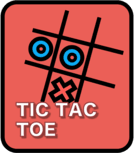

El objetivo es obtener 3 en fila, horizontal, vertical o diagonal, antes que el adversario. Si todos los espacios se llenan sin un ganador, es empate.

## A.2 4 IN A ROW

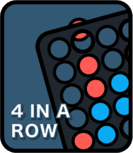

El objetivo es obtener 4 en fila antes que el adversario. Cada pieza se coloca en una columna y cae hasta el espacio más bajo disponible. Cuando todas las columnas están llenas sin un ganador, es empate.

1. Presente el diseño del problema y del modelo
2. Implemente los componentes necesarios para solucionar el problema
3. Use el algoritmo de búsqueda correspondiente para solucionar el problema
4. Presente la secuencia de acciones que soluciona el problema usando el algoritmo implementado

In [20]:
# ============================================================
# 1. Represente el diseño del problema seleccionado
# ============================================================

In [21]:
# ============================================================
# 2. Agregue lo necesario a su representación del problema
# ============================================================

In [22]:
# ============================================================
# 3. Use el algoritmo alpha-beta aplicándola al problema de seleccionado
# ============================================================

In [23]:
# ============================================================
# 4. Use la función para jugar como MAX
# mostrando la secuencia de acciones y la utilidad final
# ============================================================

# III. RETROSPECTIVA

1. ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre) 
2. ¿Cuál es el estado actual del laboratorio? ¿Por qué?
3. ¿Cuál consideran fue el mayor logro? ¿Por qué? 
4. ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?
5. ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados? 